In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import scipy.io as sio
import tensorflow as tf
from tqdm import trange


import models

In [2]:
cov1 = np.array(
    [
        [1/2**2, 0.05],
        [0.05, 1/3**2],
    ]
)
cov2 = np.array(
    [
        [1/4**2, -0.05],
        [-0.05, 1/2**2],
    ]
)
T = 0.9
t0 = 0.1
eps = 0.5
mu1 = np.array([0.5, 0.5]).reshape([1, -1])
mu2 = np.array([-0.5, -0.5]).reshape([1, -1])


def fn(x):
    T1 = (x - mu1) @ np.linalg.inv(cov1)
    T1 = np.einsum("Nk,kN->N", T1, (x - mu1).T)
    f1 = 1 / np.sqrt((2*np.pi) ** 2 * np.linalg.det(cov1)) * np.exp(-T1/2)
    T2 = (x - mu2) @ np.linalg.inv(cov2)
    T2 = np.einsum("Nk,kN->N", T2, (x - mu2).T)
    f2 = 1 / np.sqrt((2*np.pi) ** 2 * np.linalg.det(cov2)) * np.exp(-T2/2)
    return 0.5 * f1 + 0.5 * f2


def C(t, cov):
    return np.sqrt((2*np.pi) ** 2 * np.linalg.det(cov + eps * t * np.eye(2)))


def s(Y, t):
    T1 = (Y - mu1) @ np.linalg.inv(cov1 + eps * t * np.eye(2))
    T1 = np.einsum("Nk,kN->N", T1, (Y - mu1).T)
    T2 = (Y - mu2) @ np.linalg.inv(cov2 + eps * t * np.eye(2))
    T2 = np.einsum("Nk,kN->N", T2, (Y - mu2).T)
    A = 1/2 * 1/C(t, cov1) * np.exp(-T1/2) + 1/2 * 1/C(t, cov2) * np.exp(-T2/2)
    
    B1 = 1/C(t, cov1) * np.linalg.inv(cov1 + eps*t*np.eye(2)) @ (Y - mu1).T * np.exp(-T1/2)
    B2 = 1/C(t, cov2) * np.linalg.inv(cov2 + eps*t*np.eye(2)) @ (Y - mu2).T * np.exp(-T2/2)
    
    return - (0.5 * B1.T + 0.5 * B2.T) / A[:, None]

#### Use pretrained model

In [3]:
N = 1000000
model = models.NN(units=50, name="nn_{}".format(str(N)), eps=np.array(eps), activation=tf.tanh)
model.restore()

In [4]:
@tf.function
def forward(y1, y2, t):
    return model.nn.call(tf.concat([t, y1, y2], axis=-1))

In [5]:
yt = np.array([-0.9, 0.9]).reshape([1, -1])

dt = 0.001
t = 0
M = int(1e6)
zts = np.tile(yt, [M, 1])
N = int(np.ceil((T - t0) / dt))
for i in trange(N):
    update = forward(
        tf.constant(zts[:, 0:1], tf.float32),
        tf.constant(zts[:, 1:2], tf.float32),
        (T - t) * tf.ones(shape=[M, 1]),
    ).numpy()
    zts = zts + eps * update * dt + \
        np.sqrt(eps) * np.random.normal(size=zts.shape) * np.sqrt(dt)
    t = t + dt
# zts = np.stack(zts, axis=0)

100%|████████████████████████████████████████████████████████████████████████████████| 800/800 [02:22<00:00,  5.61it/s]


In [6]:
x = np.linspace(-1.5, 1.5, 101)
y = np.linspace(-1.5, 1.5, 101)
xx, yy = np.meshgrid(x, y)
xx = xx.reshape([-1, 1])
yy = yy.reshape([-1, 1])
inputs = np.concatenate([xx, yy], axis=-1)

out = fn(inputs)
f = out.reshape([101, 101])
levels = np.linspace(np.min(f), np.max(f), 50)

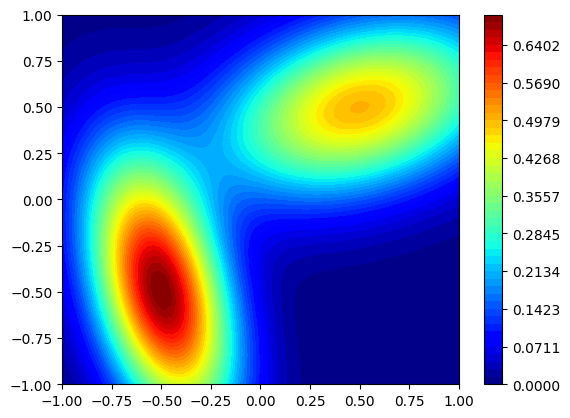

In [7]:
c = plt.contourf(
    xx.reshape([101, 101]), 
    yy.reshape([101, 101]), 
    f, 
    cmap=colormaps["jet"],
    levels=levels,
)

idx = 0
# plt.plot(zts[::5, idx, 0], zts[::5, idx, 1], "y-", alpha=1)
# plt.plot(zts[0, idx, 0], zts[0, idx, 1], "wo", label="$Y_T$", markersize=10)
# plt.plot(zts[-1, idx, 0], zts[-1, idx, 1], "w*", label="$Y_0$", markersize=10)
out = fn(inputs)


plt.xlim([-1., 1.])
plt.ylim([-1., 1.])
# plt.legend()
plt.colorbar()
plt.show()

#### compute the posterior analytically

In [8]:
x = np.linspace(-1., 1., 1001)
y = np.linspace(-1., 1., 1001)
xx, yy = np.meshgrid(x, y)
xx = xx.reshape([-1, 1])
yy = yy.reshape([-1, 1])
inputs = np.concatenate([xx, yy], axis=-1)

In [9]:
T1 = (inputs - mu1) @ np.linalg.inv(cov1 + eps * t0 * np.eye(2))
T1 = np.einsum("Nk,kN->N", T1, (inputs - mu1).T)
T2 = (inputs - mu2) @ np.linalg.inv(cov2 + eps * t0 * np.eye(2))
T2 = np.einsum("Nk,kN->N", T2, (inputs - mu2).T)
A = 1/2 * 1/C(t0, cov1) * np.exp(-T1/2) + 1/2 * 1/C(t0, cov2) * np.exp(-T2/2)

D = 1/np.sqrt((2*np.pi*eps*(T-t0)) ** 2) * np.exp(-1/2/eps/(T-t0)*np.sum((inputs-yt) ** 2, axis=-1))

T1 = (yt - mu1) @ np.linalg.inv(cov1 + eps * T * np.eye(2))
T1 = np.einsum("Nk,kN->N", T1, (yt - mu1).T)
T2 = (yt - mu2) @ np.linalg.inv(cov2 + eps * T * np.eye(2))
T2 = np.einsum("Nk,kN->N", T2, (yt - mu2).T)
B = 1/2 * 1/C(T, cov1) * np.exp(-T1/2) + 1/2 * 1/C(T, cov2) * np.exp(-T2/2)

f = A * D / B
f = f.reshape([1001, 1001])

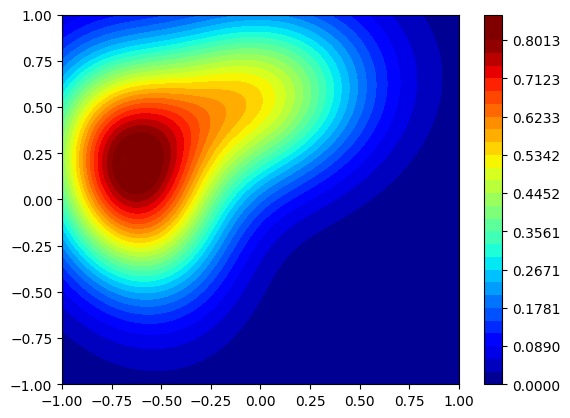

In [10]:
levels = np.linspace(np.min(f), np.max(f), 30)
# log_min = np.log(np.min(f))
# log_max = np.log(np.max(f))
# levels = np.exp(np.linspace(log_min, log_max, 100))
c = plt.contourf(
    xx.reshape([1001, 1001]), 
    yy.reshape([1001, 1001]), 
    f, 
    cmap=colormaps["jet"],
    levels=levels,
)
plt.xlim([-1., 1.])
plt.ylim([-1., 1.])
plt.clim(0, 0.8)
plt.colorbar()
plt.show()

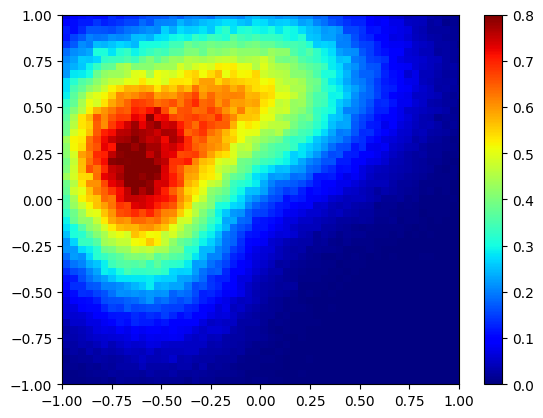

In [11]:
plt.hist2d(zts[:, 0], zts[:, 1], bins=(100, 100), density=True, cmap=colormaps["jet"])
plt.xlim([-1., 1.])
plt.ylim([-1., 1.])
plt.clim(0, 0.8)
plt.colorbar()
plt.show()

In [12]:
sio.savemat(
    "./outputs/sgm1.mat",
    {
        "xx": xx, "yy": yy, "f": f,
        "samples": zts
    }
)